# Venn–Abers statico e rolling

Questo notebook lascia invariati feature engineering, iperparametri Optuna e modello CatBoost probabilistico del notebook 02. Confronta:

- probabilità CatBoost raw;
- Venn–Abers statico, calibrato su marzo 2026;
- Venn–Abers rolling causale, aggiornato una volta al giorno.

La finestra rolling (30, 60 o 90 giorni) viene scelta esclusivamente sui sei fold storici. Aprile 2026 resta un test intatto. Durante il replay di aprile, ogni giornata usa solo etichette divenute disponibili entro la mezzanotte precedente. `p0` e `p1` sono output multiprobabilistici Venn–Abers, non intervalli di confidenza classici.


In [1]:
from importlib.metadata import version
import json
from pathlib import Path

from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'gnss_weather').exists():
    ROOT = ROOT.parent

from gnss_weather.forecasting import brier_score, reliability_table
from gnss_weather.venn_abers import calibrate_venn_abers, rolling_calibrate_venn_abers

DATASET_PATH = ROOT / 'data/derived/ml/MATE00ITA_rain_hourly_2024-07-01_2026-08-20.csv'
BASE_METRICS_PATH = ROOT / 'data/derived/ml/MATE00ITA_catboost_2y_walkforward_mar_apr_metrics.json'
CALIBRATION_START = pd.Timestamp('2026-03-01', tz='UTC')
CALIBRATION_END_EXCLUSIVE = pd.Timestamp('2026-04-01', tz='UTC')
TEST_START = CALIBRATION_END_EXCLUSIVE
TEST_END_EXCLUSIVE = pd.Timestamp('2026-05-01', tz='UTC')
WINDOW_CANDIDATES_DAYS = (30, 60, 90)
MIN_EXAMPLES_PER_CLASS = 20
RANDOM_SEED = 42
OUTPUT_DIR = ROOT / 'data/derived/ml'
MODEL_DIR = ROOT / 'data/models'

{'venn-abers': version('venn-abers'), 'candidate_windows_days': WINDOW_CANDIDATES_DAYS}


{'venn-abers': '1.5.4', 'candidate_windows_days': (30, 60, 90)}

## Dati e modello base

Il modello finale del notebook 02 è addestrato solo fino a febbraio 2026. Marzo è il warm-up iniziale del calibratore e aprile è il test. Il target è la pioggia nell'ora successiva, quindi alla mezzanotte sono disponibili tutte le etichette relative alle ore del giorno precedente.


In [2]:
base_metrics = json.loads(BASE_METRICS_PATH.read_text(encoding='utf-8'))
feature_columns = base_metrics['feature_columns']
frame = pd.read_csv(DATASET_PATH)
frame['epoch_utc'] = pd.to_datetime(frame['epoch_utc'], utc=True)
frame['target_window_end_utc'] = pd.to_datetime(frame['target_window_end_utc'], utc=True)
frame = frame.set_index('epoch_utc').sort_index()

proper_training = frame.loc[frame.index < CALIBRATION_START].copy()
calibration = frame.loc[
    (frame.index >= CALIBRATION_START) & (frame.index < CALIBRATION_END_EXCLUSIVE)
].copy()
test = frame.loc[(frame.index >= TEST_START) & (frame.index < TEST_END_EXCLUSIVE)].copy()
assert proper_training.index.max() < calibration.index.min() < test.index.min()
assert calibration['is_rain'].nunique() == 2

model_path = ROOT / base_metrics['probability_model_raw']['model_path']
probability_model = CatBoostClassifier()
probability_model.load_model(model_path)

pd.DataFrame({
    'start': [proper_training.index.min(), calibration.index.min(), test.index.min()],
    'end': [proper_training.index.max(), calibration.index.max(), test.index.max()],
    'rows': [len(proper_training), len(calibration), len(test)],
    'rain_hours': [int(proper_training.is_rain.sum()), int(calibration.is_rain.sum()), int(test.is_rain.sum())],
    'rain_fraction': [proper_training.is_rain.mean(), calibration.is_rain.mean(), test.is_rain.mean()],
}, index=['proper_training', 'calibration_warmup', 'test'])


,start,end,rows,rain_hours,rain_fraction
proper_training,2024-07-01 03:00:00+00:00,2026-02-27 23:00:00+00:00,11466,1478,0.128903
calibration_warmup,2026-03-01 03:00:00+00:00,2026-03-31 23:00:00+00:00,741,203,0.273954
test,2026-04-01 00:00:00+00:00,2026-04-30 23:00:00+00:00,666,98,0.147147


## Scelta della finestra senza contaminare il test

Per ogni fold storico addestriamo CatBoost prima dell'intera finestra massima di calibrazione. Le probabilità dei 90 giorni precedenti e della validazione sono quindi out-of-sample rispetto a quel modello. Dentro la validazione Venn–Abers viene aggiornato giornalmente. Una finestra con meno di 20 esempi per classe si espande alla candidata successiva.

Gli iperparametri CatBoost sono quelli già scelti da Optuna nel notebook 02: qui non viene svolto un nuovo tuning del classificatore.


In [3]:
BASE_PARAMETERS = dict(
    loss_function='Logloss', random_seed=RANDOM_SEED, allow_writing_files=False,
    thread_count=-1, bootstrap_type='Bayesian', verbose=False,
)
probability_parameters = base_metrics['probability_model_raw']['best_hyperparameters']

def naive_utc(index):
    return index.tz_convert('UTC').tz_localize(None).to_numpy(dtype='datetime64[ns]')

def binary_log_loss(y_true, probability):
    truth = np.asarray(y_true, dtype=float)
    predicted = np.clip(np.asarray(probability, dtype=float), 1e-15, 1.0 - 1e-15)
    return float(np.mean(-(truth * np.log(predicted) + (1.0 - truth) * np.log(1.0 - predicted))))

def expected_calibration_error(table):
    error = (table['predicted_probability'] - table['observed_frequency']).abs()
    return float(np.average(error, weights=table['count']))

historical_predictions = {window: [] for window in WINDOW_CANDIDATES_DAYS}
fold_diagnostics = []
maximum_window = max(WINDOW_CANDIDATES_DAYS)

for fold_number, fold in enumerate(base_metrics['walk_forward']['folds'], start=1):
    validation_start = pd.Timestamp(fold['validation_start']).tz_convert('UTC')
    validation_end = pd.Timestamp(fold['validation_end']).tz_convert('UTC')
    history_start = validation_start - pd.Timedelta(days=maximum_window)

    # Exclude the calibration history from fitting; target_window_end enforces the +1 h gap.
    fold_training = frame.loc[frame['target_window_end_utc'] <= history_start].copy()
    fold_history = frame.loc[(frame.index >= history_start) & (frame.index < validation_start)].copy()
    fold_validation = frame.loc[(frame.index >= validation_start) & (frame.index <= validation_end)].copy()
    assert not fold_training.empty and not fold_history.empty and not fold_validation.empty

    fold_model = CatBoostClassifier(**BASE_PARAMETERS, **probability_parameters)
    fold_model.fit(fold_training[feature_columns], fold_training['is_rain'].astype(int))
    history_score = fold_model.predict_proba(fold_history[feature_columns])[:, 1]
    validation_score = fold_model.predict_proba(fold_validation[feature_columns])[:, 1]

    for window in WINDOW_CANDIDATES_DAYS:
        fallback = tuple(candidate for candidate in WINDOW_CANDIDATES_DAYS if candidate > window)
        rolling = rolling_calibrate_venn_abers(
            p_history=history_score,
            y_history=fold_history['is_rain'].to_numpy(dtype=int),
            history_times=naive_utc(fold_history.index),
            p_test=validation_score,
            y_test=fold_validation['is_rain'].to_numpy(dtype=int),
            test_times=naive_utc(fold_validation.index),
            window_days=window,
            fallback_window_days=fallback,
            min_per_class=MIN_EXAMPLES_PER_CLASS,
        )
        part = pd.DataFrame({
            'is_rain': fold_validation['is_rain'].to_numpy(dtype=int),
            'probability': rolling.probability,
            'effective_window_days': rolling.effective_window_days,
            'fold': fold_number,
        }, index=fold_validation.index)
        historical_predictions[window].append(part)
        fold_diagnostics.append({
            'fold': fold_number,
            'requested_window_days': window,
            'brier': brier_score(part['is_rain'], part['probability']),
            'fallback_fraction': float((part['effective_window_days'] > window).mean()),
        })

window_rows = []
for window, parts in historical_predictions.items():
    pooled = pd.concat(parts).sort_index()
    reliability = reliability_table(pooled['is_rain'], pooled['probability'], bins=10)
    window_rows.append({
        'window_days': window,
        'brier': brier_score(pooled['is_rain'], pooled['probability']),
        'log_loss': binary_log_loss(pooled['is_rain'], pooled['probability']),
        'ece': expected_calibration_error(reliability),
        'fallback_fraction': float((pooled['effective_window_days'] > window).mean()),
        'rows': len(pooled),
    })

window_selection = pd.DataFrame(window_rows).sort_values(['brier', 'log_loss']).reset_index(drop=True)
selected_window_days = int(window_selection.iloc[0]['window_days'])
window_selection


C:\Users\vince\repos\gnss-weather\.venv\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


C:\Users\vince\repos\gnss-weather\.venv\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


C:\Users\vince\repos\gnss-weather\.venv\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


C:\Users\vince\repos\gnss-weather\.venv\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


,window_days,brier,log_loss,ece,fallback_fraction,rows
0,30,0.085432,0.277999,0.019961,0.160034,7161
1,60,0.086162,0.280080,0.023662,0.000000,7161
2,90,0.087144,0.282702,0.018659,0.000000,7161


In [4]:
pd.DataFrame(fold_diagnostics).pivot(index='fold', columns='requested_window_days', values=['brier', 'fallback_fraction'])


brier                     fallback_fraction       \
requested_window_days        30        60        90                30   60   
fold                                                                         
1                      0.118950  0.122679  0.132063          0.000000  0.0   
2                      0.046994  0.046232  0.047841          0.076372  0.0   
3                      0.039439  0.039552  0.037286          0.601831  0.0   
4                      0.100110  0.094869  0.094969          0.150358  0.0   
5                      0.087702  0.097527  0.093526          0.000000  0.0   
6                      0.122829  0.122648  0.122630          0.056206  0.0   

                            
requested_window_days   90  
fold                        
1                      0.0  
2                      0.0  
3                      0.0  
4                      0.0  
5                      0.0  
6                      0.0

## Replay causale su aprile 2026

Lo statico usa sempre marzo. Il rolling parte dallo stesso warm-up, poi all'inizio di ogni giorno di aprile elimina i dati fuori finestra e incorpora le etichette dei giorni di aprile già conclusi. Se necessario espande la finestra fino a 90 giorni. Aprile non ha partecipato alla scelta della finestra.


In [5]:
p_cal = probability_model.predict_proba(calibration[feature_columns])
p_test = probability_model.predict_proba(test[feature_columns])
raw_probability = p_test[:, 1]

static_va = calibrate_venn_abers(
    p_cal=p_cal,
    y_cal=calibration['is_rain'].to_numpy(dtype=int),
    p_test=p_test,
)
static_probability = static_va.probability

selected_fallbacks = tuple(window for window in WINDOW_CANDIDATES_DAYS if window > selected_window_days)
rolling_va = rolling_calibrate_venn_abers(
    p_history=p_cal,
    y_history=calibration['is_rain'].to_numpy(dtype=int),
    history_times=naive_utc(calibration.index),
    p_test=p_test,
    y_test=test['is_rain'].to_numpy(dtype=int),
    test_times=naive_utc(test.index),
    window_days=selected_window_days,
    fallback_window_days=selected_fallbacks,
    min_per_class=MIN_EXAMPLES_PER_CLASS,
)
rolling_probability = rolling_va.probability

pd.Series({
    'selected_window_days': selected_window_days,
    'test_fallback_fraction': np.mean(rolling_va.effective_window_days > selected_window_days),
    'median_calibration_size': np.median(rolling_va.calibration_size),
    'median_multiprobability_width': np.median(rolling_va.multiprobability_width),
    'p95_multiprobability_width': np.quantile(rolling_va.multiprobability_width, 0.95),
})


selected_window_days              30.000000
test_fallback_fraction             0.000000
median_calibration_size          693.000000
median_multiprobability_width      0.015152
p95_multiprobability_width         0.074703
dtype: float64

In [6]:
monthly_climatology = proper_training.groupby(proper_training.index.month)['is_rain'].mean()
climatology_probability = np.asarray([monthly_climatology.loc[month] for month in test.index.month])
climatology_brier = brier_score(test['is_rain'], climatology_probability)

test_metrics = []
for name, probability in {
    'raw_catboost': raw_probability,
    'venn_abers_static': static_probability,
    'venn_abers_rolling': rolling_probability,
}.items():
    score = brier_score(test['is_rain'], probability)
    reliability = reliability_table(test['is_rain'], probability, bins=10)
    test_metrics.append({
        'method': name,
        'brier': score,
        'brier_skill_vs_monthly_climatology': 1.0 - score / climatology_brier,
        'log_loss': binary_log_loss(test['is_rain'], probability),
        'ece': expected_calibration_error(reliability),
    })
test_metrics = pd.DataFrame(test_metrics).set_index('method')
test_metrics


,brier,brier_skill_vs_monthly_climatology,log_loss,ece
method,,,,
raw_catboost,0.067683,0.468289,0.226247,0.056244
venn_abers_static,0.075862,0.404033,0.248895,0.071529
venn_abers_rolling,0.077239,0.393218,0.248867,0.057940


## Reliability diagram

I bin hanno numerosità approssimativamente uguale e vengono costruiti separatamente per ogni metodo. Questo rende leggibile la calibrazione di probabilità a gradini, ma l'ECE resta una statistica dipendente dal binning.


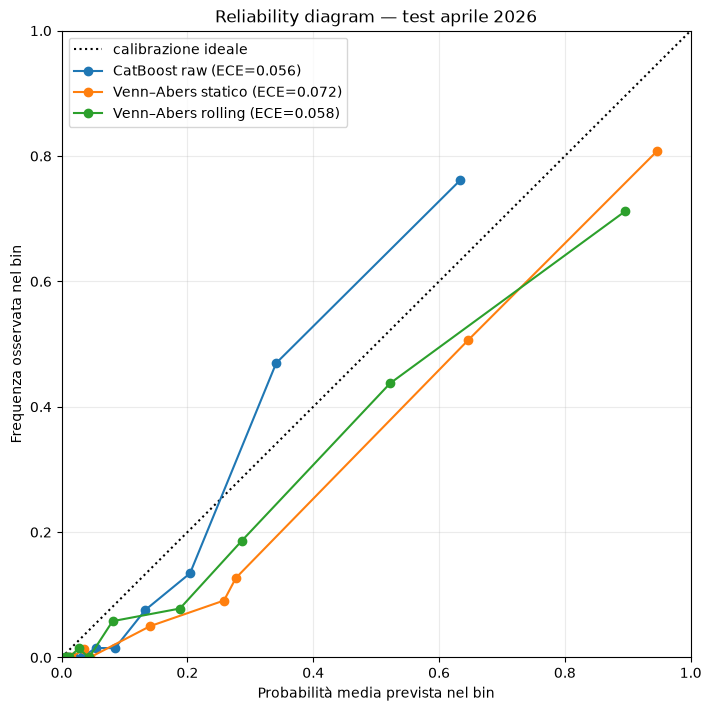

In [7]:
reliability_tables = {
    'CatBoost raw': reliability_table(test['is_rain'], raw_probability, bins=10),
    'Venn–Abers statico': reliability_table(test['is_rain'], static_probability, bins=10),
    'Venn–Abers rolling': reliability_table(test['is_rain'], rolling_probability, bins=10),
}
fig, axis = plt.subplots(figsize=(7, 7), constrained_layout=True)
axis.plot([0, 1], [0, 1], color='black', linestyle=':', label='calibrazione ideale')
for label, table in reliability_tables.items():
    ece = expected_calibration_error(table)
    axis.plot(table['predicted_probability'], table['observed_frequency'], marker='o', label=f'{label} (ECE={ece:.3f})')
axis.set(
    xlim=(0, 1), ylim=(0, 1),
    xlabel='Probabilità media prevista nel bin',
    ylabel='Frequenza osservata nel bin',
    title='Reliability diagram — test aprile 2026',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()


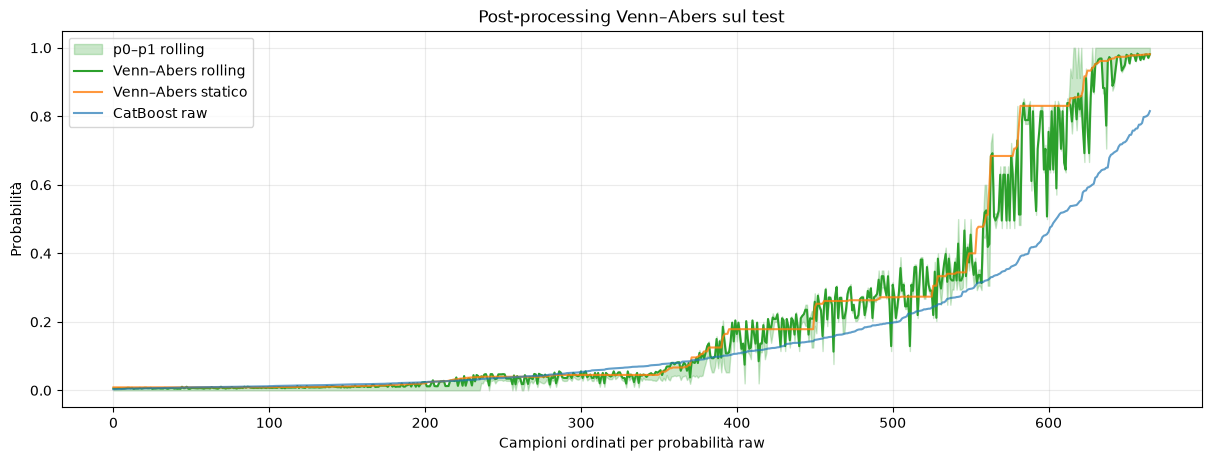

In [8]:
order = np.argsort(raw_probability)
x = np.arange(len(test))
fig, axis = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
axis.fill_between(x, rolling_va.p0[order], rolling_va.p1[order], alpha=0.25, color='tab:green', label='p0–p1 rolling')
axis.plot(x, rolling_probability[order], color='tab:green', label='Venn–Abers rolling')
axis.plot(x, static_probability[order], color='tab:orange', alpha=0.8, label='Venn–Abers statico')
axis.plot(x, raw_probability[order], color='tab:blue', alpha=0.7, label='CatBoost raw')
axis.set(xlabel='Campioni ordinati per probabilità raw', ylabel='Probabilità', title='Post-processing Venn–Abers sul test')
axis.grid(alpha=0.25)
axis.legend()
plt.show()


## Artefatti

Il file NPZ contiene il warm-up di marzo. Nel deployment rolling questo stato non è immutabile: va mantenuto come buffer temporale di score raw, etichette e timestamp, aggiornandolo quando il target dell'ora precedente diventa osservabile.


In [9]:
calibration_state_path = MODEL_DIR / 'rain_venn_abers_rolling_warmup_mar_2026.npz'
np.savez_compressed(
    calibration_state_path,
    p_cal=p_cal,
    y_cal=calibration['is_rain'].to_numpy(dtype=np.int8),
    epoch_utc=naive_utc(calibration.index),
    selected_window_days=np.int16(selected_window_days),
)

predictions = pd.DataFrame({
    'epoch_utc': test.index,
    'is_rain': test['is_rain'].to_numpy(dtype=int),
    'rain_next_hour_mm': test['rain_next_hour_mm'].to_numpy(),
    'probability_raw': raw_probability,
    'probability_venn_abers_static': static_probability,
    'probability_venn_abers_rolling': rolling_probability,
    'rolling_venn_p0': rolling_va.p0,
    'rolling_venn_p1': rolling_va.p1,
    'rolling_multiprobability_width': rolling_va.multiprobability_width,
    'rolling_effective_window_days': rolling_va.effective_window_days,
    'rolling_calibration_size': rolling_va.calibration_size,
    'monthly_climatology_probability': climatology_probability,
})
predictions_path = OUTPUT_DIR / 'MATE00ITA_venn_abers_rolling_apr_test_predictions.csv'
predictions.to_csv(predictions_path, index=False)

window_selection_path = OUTPUT_DIR / 'MATE00ITA_venn_abers_rolling_window_selection.csv'
window_selection.to_csv(window_selection_path, index=False)
fold_diagnostics_path = OUTPUT_DIR / 'MATE00ITA_venn_abers_rolling_fold_diagnostics.csv'
pd.DataFrame(fold_diagnostics).to_csv(fold_diagnostics_path, index=False)
for label, table in reliability_tables.items():
    safe_label = label.lower().replace('–', '_').replace(' ', '_')
    table.to_csv(OUTPUT_DIR / f'MATE00ITA_venn_abers_apr_reliability_{safe_label}.csv', index=False)

metrics = {
    'venn_abers_version': version('venn-abers'),
    'base_model_path': str(model_path.relative_to(ROOT)),
    'class_weighting': 'none',
    'rolling_policy': {
        'update_frequency': 'daily at 00:00 UTC',
        'candidate_windows_days': list(WINDOW_CANDIDATES_DAYS),
        'selected_window_days': selected_window_days,
        'minimum_examples_per_class': MIN_EXAMPLES_PER_CLASS,
        'selection': 'minimum pooled historical walk-forward Brier; April excluded',
    },
    'calibration_warmup': {
        'start': calibration.index.min().isoformat(), 'end': calibration.index.max().isoformat(),
        'rows': len(calibration), 'rain_hours': int(calibration.is_rain.sum()),
        'rain_fraction': float(calibration.is_rain.mean()),
    },
    'test': {
        'start': test.index.min().isoformat(), 'end': test.index.max().isoformat(),
        'rows': len(test), 'rain_hours': int(test.is_rain.sum()),
        'rain_fraction': float(test.is_rain.mean()),
        'monthly_climatology_brier': climatology_brier,
        'methods': test_metrics.reset_index().set_index('method').to_dict(orient='index'),
    },
    'window_selection_path': str(window_selection_path.relative_to(ROOT)),
    'fold_diagnostics_path': str(fold_diagnostics_path.relative_to(ROOT)),
    'calibration_state_path': str(calibration_state_path.relative_to(ROOT)),
    'predictions_path': str(predictions_path.relative_to(ROOT)),
}
metrics_path = OUTPUT_DIR / 'MATE00ITA_venn_abers_rolling_apr_test_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2) + '\n', encoding='utf-8')
metrics_path, predictions_path, window_selection_path, calibration_state_path


(WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_venn_abers_rolling_apr_test_metrics.json'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_venn_abers_rolling_apr_test_predictions.csv'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_venn_abers_rolling_window_selection.csv'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/models/rain_venn_abers_rolling_warmup_mar_2026.npz'))

## Interpretazione

La finestra mobile è una strategia adattiva, non una garanzia contro ogni distribution shift. Va giudicata sul confronto walk-forward e sul test intatto. All'inizio di aprile il rolling dispone soltanto del warm-up di marzo; col passare dei giorni incorpora il nuovo regime senza mai guardare etichette future.
